# 🛰️ Sentinel-X — Analyse des données 

## 🎯 Objectif de l'analyse

L’objectif de cette analyse est d’étudier les données produites par le système Sentinel-X afin d’identifier les comportements normaux, les évolutions inhabituelles et les situations potentiellement dangereuses.

L’analyse vise notamment à exploiter les mesures de température, d’humidité, de gaz et de présence, ainsi que leurs variations dans le temps, afin de préparer un modèle de classification basé sur **Random Forest**.

À terme, le modèle devra être capable de distinguer plusieurs types de situations :

- **NORMAL**
- **PRE_ALERTE**
- **SURCHAUFFE**
- **FUITE_GAZ**
- **INTRUSION**
- **INCIDENT_COMBINE**

L’objectif final est donc de construire un système capable de détecter et de classer automatiquement les situations à risque, afin de permettre au dashboard Sentinel-X de déclencher les alertes adaptées.

## 🔍 Description des données

Les données utilisées pour cette étude proviennent du système IoT Sentinel-X basé sur un **ESP32**.

L’architecture de détection repose sur trois détecteurs :

- **DHT22** : détecteur utilisé pour mesurer la température et l’humidité ;
- **MQ-2** : détecteur de gaz et de fumée ;
- **PIR** : détecteur de présence et de mouvement.

L’ESP32 constitue le nœud Edge du système. Il récupère, structure et transmet les données sous forme de messages JSON sécurisés via **MQTTS**.

Pour constituer un premier jeu de données suffisamment riche pour l’analyse et l’apprentissage automatique, un mode de génération contrôlée a été intégré au firmware de l’ESP32. Il produit des valeurs diversifiées respectant les plages définies pour les différents détecteurs ainsi que des variations progressives entre deux observations.

Le dataset brut contient **1 observations**.

## 🚀 Lancer le projet

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement du dataset brut Sentinel-X
df = pd.read_json("../data/sentinel_1425brute.jsonl", lines=True)

# Affichage des dimensions
print("Dimensions du dataset :", df.shape)

# Aperçu des 5 premières observations
df.head()

Dimensions du dataset : (1425, 9)


,sample,temperature,humidity,gas_raw,presence,delta_temp,delta_humidity,delta_gas,presence_change
0,1,37.55,35.46,2308,False,0.00,0.00,0,0
1,2,37.02,35.58,2421,True,-0.53,0.12,113,1
2,3,36.15,36.37,2451,True,-0.87,0.79,30,0
3,4,35.60,37.18,2687,True,-0.55,0.80,236,0
4,5,34.65,38.29,2696,True,-0.95,1.11,9,0


In [34]:
# Examiner la structure et les types des variables
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1425 entries, 0 to 1424
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample           1425 non-null   int64  
 1   temperature      1425 non-null   float64
 2   humidity         1425 non-null   float64
 3   gas_raw          1425 non-null   int64  
 4   presence         1425 non-null   bool   
 5   delta_temp       1425 non-null   float64
 6   delta_humidity   1425 non-null   float64
 7   delta_gas        1425 non-null   int64  
 8   presence_change  1425 non-null   int64  
dtypes: bool(1), float64(4), int64(4)
memory usage: 90.6 KB


## 📊 Analyse exploratoire des données (EDA)

Cette étape permet d’obtenir une première vue d’ensemble du comportement des variables du système Sentinel-X.

Nous allons étudier les principales statistiques descriptives afin d’observer :

- les valeurs minimales et maximales ;
- la moyenne des mesures ;
- la dispersion des données ;
- les quartiles ;
- la répartition générale des variables numériques.

Cette première analyse permettra de mieux comprendre le comportement de la température, de l’humidité, du niveau de gaz et des différentes variations avant de passer à une analyse plus détaillée et à la création des classes de scénario.

In [35]:
# Statistiques descriptives des variables numériques
df[
    [
        "temperature",
        "humidity",
        "gas_raw",
        "delta_temp",
        "delta_humidity",
        "delta_gas"
    ]
].describe().round(2)

,temperature,humidity,gas_raw,delta_temp,delta_humidity,delta_gas
count,1425.00,1425.00,1425.00,1425.00,1425.00,1425.00
mean,34.39,50.76,2222.64,0.01,0.02,0.67
std,5.44,6.24,831.71,0.53,1.38,98.98
min,22.26,34.09,502.00,-1.20,-2.00,-250.00
25%,30.17,45.98,1436.00,-0.28,-1.21,-55.00
50%,32.83,51.05,2105.00,0.02,0.00,3.00
75%,40.33,55.40,3127.00,0.34,1.27,67.00
max,43.86,67.52,3670.00,1.17,2.00,250.00


### ✅ Conclusion

Les statistiques descriptives montrent que les mesures présentent des niveaux variés de température, d’humidité et de gaz.

Les variables évoluent aussi bien à la hausse qu’à la baisse, ce qui met en évidence différents comportements

## 🌡️ Analyse de la température

Nous commençons par étudier la distribution de la température afin d'observer les valeurs les plus fréquentes et la manière dont les mesures sont réparties sur l'ensemble du dataset.

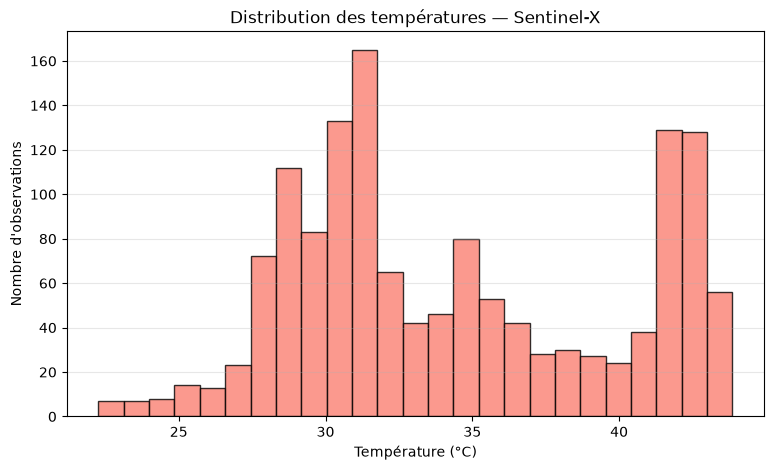

In [36]:
# Distribution des températures
plt.figure(figsize=(9, 5))

plt.hist(
    df["temperature"],
    bins=25,
    color="salmon",
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution des températures — Sentinel-X")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre d'observations")

plt.grid(axis="y", alpha=0.3)
plt.show()

### ✅ Observation

La température présente deux principales zones de concentration, autour de 30–32 °C et de 41–43 °C. Cette répartition met en évidence différents scénarios thermiques, dont des situations de température élevée.

## 💨 Analyse du niveau de gaz

Le niveau de gaz constitue une variable importante pour identifier les situations pouvant correspondre à une fuite.

Nous allons analyser sa distribution afin d'observer les valeurs les plus fréquentes et les niveaux plus élevés présents dans le dataset.

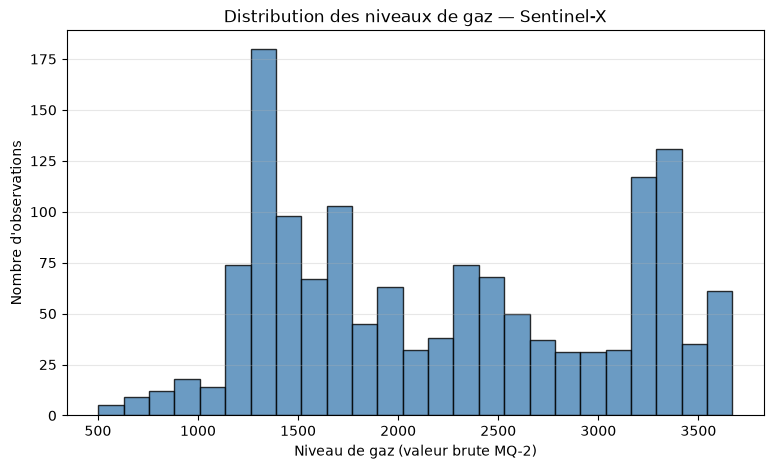

In [37]:
# Distribution des niveaux de gaz
plt.figure(figsize=(9, 5))

plt.hist(
    df["gas_raw"],
    bins=25,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution des niveaux de gaz — Sentinel-X")
plt.xlabel("Niveau de gaz (valeur brute MQ-2)")
plt.ylabel("Nombre d'observations")

plt.grid(axis="y", alpha=0.3)
plt.show()

### ✅ Observation

Les niveaux de gaz présentent une distribution irrégulière, avec deux principales concentrations autour de 1 300–1 500 et de 3 200–3 400. Ces valeurs traduisent différents scénarios simulés, notamment des situations de gaz élevé.

## 🚶 Analyse de la présence

La variable `presence` indique si une présence ou un mouvement a été détecté.

Nous allons observer la répartition entre les observations avec présence détectée (`True`) et celles sans présence (`False`).

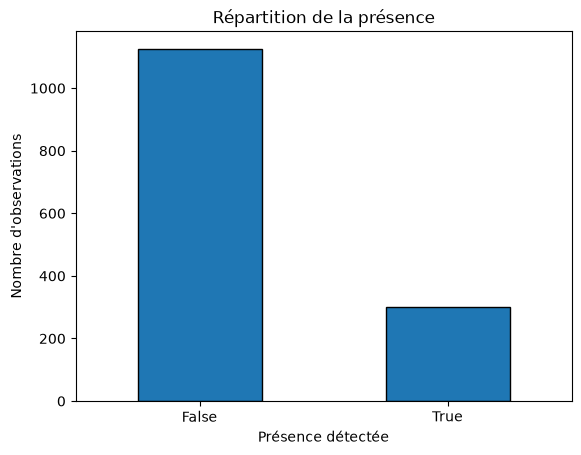

In [38]:
presence_counts = df["presence"].value_counts()

presence_counts.plot(kind="bar", edgecolor="black")

plt.xlabel("Présence détectée")
plt.ylabel("Nombre d'observations")
plt.title("Répartition de la présence")

plt.xticks(rotation=0)

plt.show()

### ✅ Observation

La majorité des observations (environ 79 %) ne présentent aucune détection de mouvement (False), contre 21 % avec une présence détectée (True). La variable presence présente donc une répartition déséquilibrée.

## 🔗 Relation entre la température et le niveau de gaz

Nous allons étudier la relation entre la température et le niveau de gaz afin de vérifier si leurs variations semblent liées.

Cette analyse est notamment intéressante pour identifier d’éventuelles situations où une hausse de température et une hausse du niveau de gaz apparaissent simultanément.

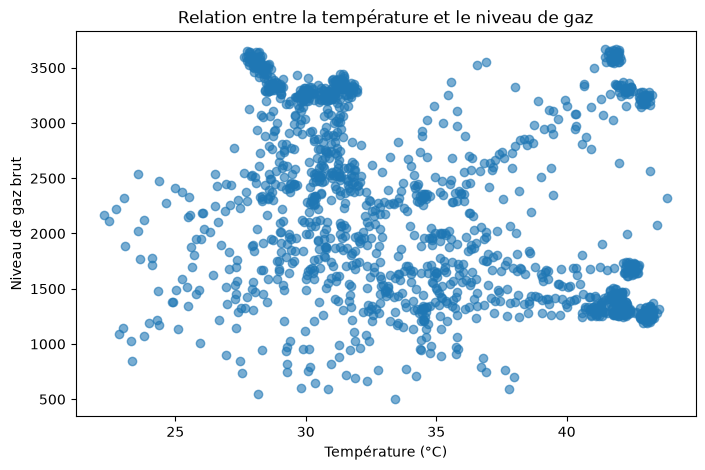

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(df["temperature"], df["gas_raw"], alpha=0.6)

plt.xlabel("Température (°C)")
plt.ylabel("Niveau de gaz brut")
plt.title("Relation entre la température et le niveau de gaz")

plt.show()

### ✅ Observation

Le nuage de points montre plusieurs regroupements distincts, sans relation linéaire évidente entre la température et le niveau de gaz. Des niveaux de gaz élevés peuvent être observés à différentes températures, traduisant la diversité des scénarios simulés.

### 📐 Corrélation entre la température et le niveau de gaz

Afin de compléter l’observation graphique, nous calculons le coefficient de corrélation entre la température et le niveau de gaz.

Une valeur proche de **1** indique une forte relation positive, une valeur proche de **-1** une forte relation négative, et une valeur proche de **0** indique peu ou pas de relation linéaire.

In [40]:
correlation = df["temperature"].corr(df["gas_raw"])

print(f"Corrélation température / gaz : {correlation:.2f}")

Corrélation température / gaz : -0.27


### ✅ Observation

Le coefficient de corrélation de −0,27 indique une faible corrélation négative entre la température et le niveau de gaz. Les deux variables présentent donc une relation linéaire peu marquée : une hausse de température ne s'accompagne pas nécessairement d'une hausse du gaz.

## 🏷️ Définition des scénarios — Critères de classification

### 🌡️ 1. Définition des niveaux de température

Afin de préparer l'étiquetage des données pour le modèle Random Forest, nous définissons trois niveaux de température adaptés à notre simulation Sentinel-X.

| Température | Niveau | Interprétation |
|---|---|---|
| 20 ≤ T < 35 °C | 🟢 Normal | Température située dans la plage de fonctionnement normale |
| 35 ≤ T < 40 °C | 🟠 Élevé | Température nécessitant une surveillance |
| T ≥ 40 °C | 🔴 Surchauffe | Température correspondant à une situation de surchauffe simulée |



### 💨 2. Définition des niveaux de gaz

Afin de préparer l'étiquetage des données pour Random Forest,
nous distinguons trois niveaux de gaz adaptés à notre simulation.

| Niveau de gaz | Catégorie | Interprétation |
|---|---|---|
| 500 ≤ G < 2 500 | 🟢 Normal | Niveau situé dans la plage normale définie |
| 2 500 ≤ G < 3 000 | 🟠 Élevé | Niveau nécessitant une surveillance |
| G ≥ 3 000 | 🔴 Critique | Niveau pouvant correspondre à une fuite de gaz simulée |



### 🏷️ 3. Définition des six scénarios

Pour préparer l'entraînement du modèle Random Forest, nous
définissons six classes représentant les différentes situations
susceptibles d'être rencontrées par le système Sentinel-X.

| Classe | Description |
|---|---|
| 🟢 NORMAL | Fonctionnement sans anomalie identifiée |
| 🟡 PRE_ALERTE | Signes précurseurs d'une situation anormale |
| 🔴 SURCHAUFFE | Température atteignant un niveau critique |
| 🟠 FUITE_GAZ | Niveau de gaz atteignant un niveau critique |
| 🟣 INTRUSION | Présence détectée dans une zone supposée interdite |
| 🚨 INCIDENT_COMBINE | Plusieurs anomalies critiques simultanées |


### ⚠️ Hypothèses

Les scénarios et seuils sont définis dans le cadre d'une simulation.

La détection de présence est considérée comme suspecte uniquement
dans l'hypothèse d'une zone à accès interdit.

Les classes obtenues représenteront des scénarios simulés,
et non des incidents réels confirmés.